In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

SEED = 42
np.random.seed(SEED)

In [5]:
df = pd.read_csv('../outputs/data/features.csv').dropna()

feature_cols = [c for c in df.columns if c not in ('rotulo','caminho')]
X = df[feature_cols].values
y = df['rotulo'].values

print('Shape X:', X.shape)
print('Classes:', np.unique(y))
print('Distribuição:\n', pd.Series(y).value_counts())

Shape X: (430, 30)
Classes: ['Broken' 'Full Black' 'Full Sour' 'Immature' 'Partial Black'
 'Partial Sour' 'Shell' 'Slight Insect Damage']
Distribuição:
 Broken                  55
Full Sour               55
Immature                55
Partial Black           55
Shell                   55
Slight Insect Damage    55
Full Black              50
Partial Sour            50
Name: count, dtype: int64


In [6]:
X_trval, X_test, y_trval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_trval, y_trval, test_size=0.2, stratify=y_trval, random_state=SEED)

print(f'Treino: {X_train.shape[0]} | Validação: {X_val.shape[0]} | Teste: {X_test.shape[0]}')

Treino: 275 | Validação: 69 | Teste: 86


In [7]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

In [8]:
modelos = {
    'knn':     KNeighborsClassifier(n_neighbors=5),
    'logreg':  LogisticRegression(max_iter=1000,  random_state=SEED),
    'svm':     SVC(kernel='rbf', probability=True, random_state=SEED),
    'rf':      RandomForestClassifier(n_estimators=300, random_state=SEED),
}

In [9]:
def avaliar(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    return {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='macro', zero_division=0),
        'y_pred':    y_pred
    }

resultados = {}

for nome, modelo in modelos.items():
    # treina com treino+validação após escolha
    modelo.fit(np.vstack([X_train_s, X_val_s]),
               np.hstack([y_train, y_val]))
    res = avaliar(modelo, X_test_s, y_test)
    resultados[nome] = res
    print(f'{nome:8s} — acc: {res["accuracy"]:.3f} | f1: {res["f1"]:.3f}')

knn      — acc: 0.640 | f1: 0.624
logreg   — acc: 0.779 | f1: 0.778
svm      — acc: 0.744 | f1: 0.735
rf       — acc: 0.802 | f1: 0.798


In [10]:
linhas = []
for nome, res in resultados.items():
    linhas.append({
        'modelo':    nome,
        'accuracy':  round(res['accuracy'], 4),
        'precision': round(res['precision'], 4),
        'recall':    round(res['recall'], 4),
        'f1':        round(res['f1'], 4)
    })

df_metricas = pd.DataFrame(linhas).sort_values('f1', ascending=False)
print(df_metricas.to_string(index=False))

modelo  accuracy  precision  recall     f1
    rf    0.8023     0.8043  0.8000 0.7980
logreg    0.7791     0.7833  0.7784 0.7782
   svm    0.7442     0.7419  0.7420 0.7352
   knn    0.6395     0.6448  0.6375 0.6237


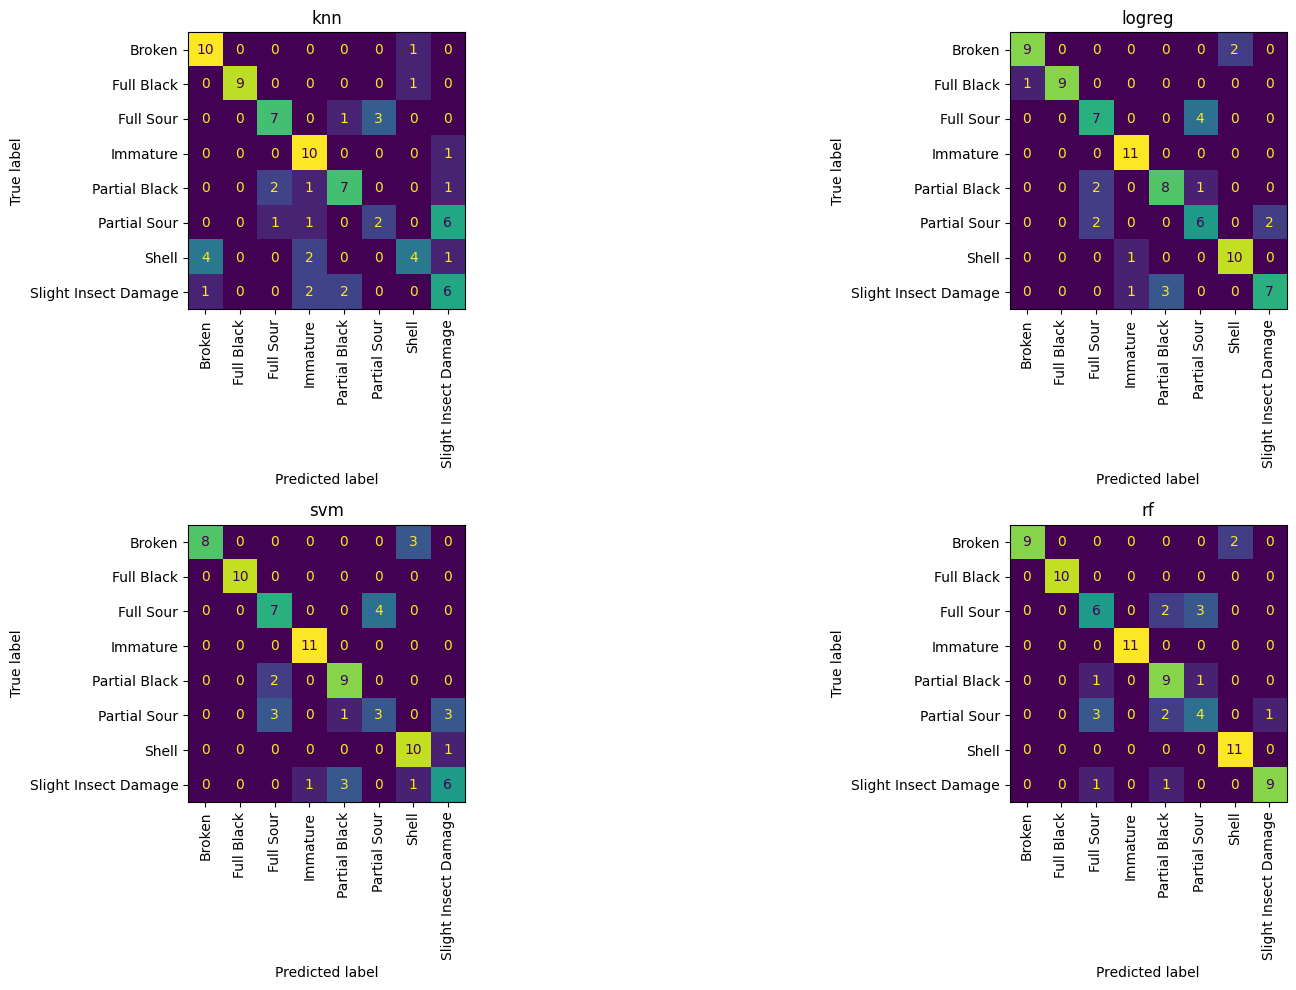

Salvo em outputs/matrizes_confusao.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, (nome, res) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=np.unique(y))
    disp = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
    disp.plot(ax=axes[idx], colorbar=False, xticks_rotation=90)
    axes[idx].set_title(f'{nome}')

plt.tight_layout()
plt.savefig('../outputs/matrizes de confusão/matrizes_confusao.png')
plt.show()
print('Salvo em outputs/matrizes_confusao.png')

Modelo: rf — 10 erros mostrados


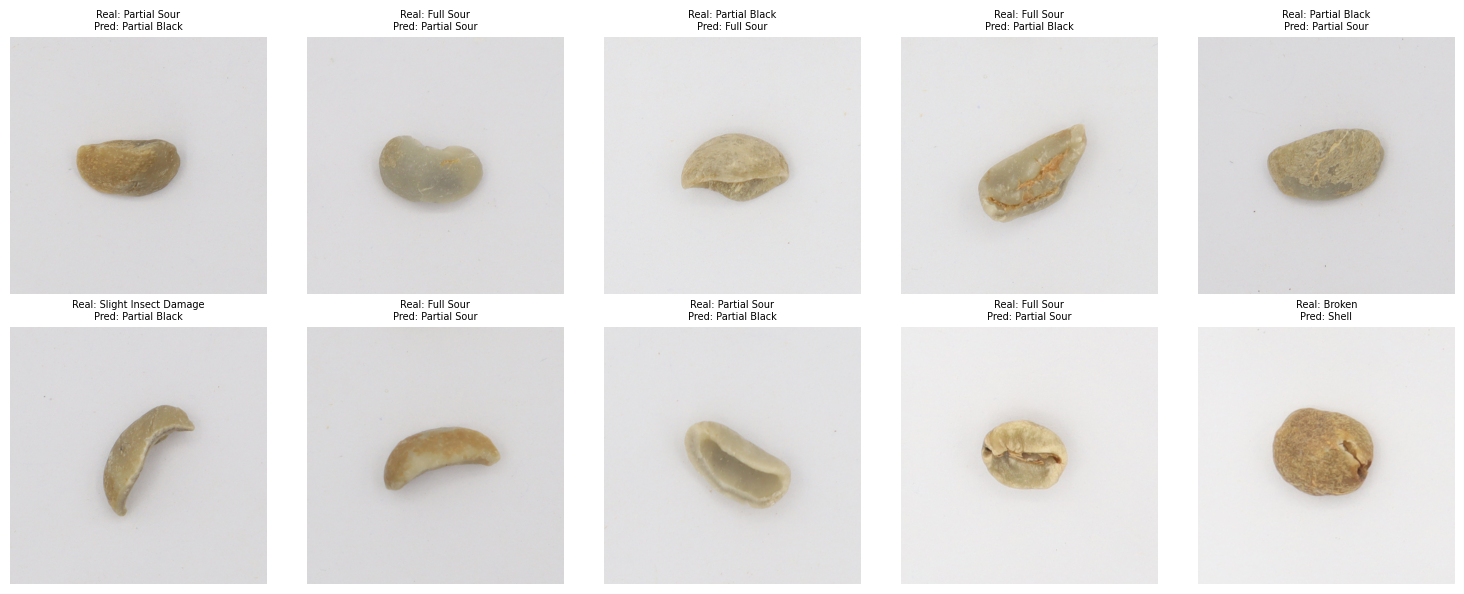

In [12]:
# pega o melhor modelo por f1
melhor_nome = df_metricas.iloc[0]['modelo']
melhor_res  = resultados[melhor_nome]
y_pred_melhor = melhor_res['y_pred']

# índices dos erros no conjunto de teste
erros_idx = np.where(y_pred_melhor != y_test)[0][:10]

print(f'Modelo: {melhor_nome} — {len(erros_idx)} erros mostrados')

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# recupera caminhos do teste
df_test = df.iloc[df.index[len(X_trval):]]
caminhos_test = df['caminho'].values[len(X_trval):]

for i, idx in enumerate(erros_idx):
    import cv2
    img = cv2.imread(caminhos_test[idx])
    if img is not None:
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Real: {y_test[idx]}\nPred: {y_pred_melhor[idx]}', fontsize=7)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../outputs/imagens de erros/imagens_erros.png')
plt.show()


In [13]:
cv_resultados = {}

for nome, modelo in modelos.items():
    scores = cross_val_score(
        modelo,
        np.vstack([X_train_s, X_val_s]),
        np.hstack([y_train, y_val]),
        cv=5, scoring='f1_macro'
    )
    cv_resultados[nome] = scores
    print(f'{nome:8s} — f1 médio: {scores.mean():.3f} (+/- {scores.std():.3f})')


knn      — f1 médio: 0.618 (+/- 0.040)
logreg   — f1 médio: 0.755 (+/- 0.050)
svm      — f1 médio: 0.685 (+/- 0.037)
rf       — f1 médio: 0.799 (+/- 0.026)


In [14]:
# pega os 2 melhores por f1
top2 = df_metricas.head(2)['modelo'].tolist()

grades = {
    'knn':    {'n_neighbors': [3, 5, 7, 9]},
    'logreg': {'C': [0.01, 0.1, 1.0, 10.0]},
    'svm':    {'C': [0.1, 1.0, 10.0, 100.0], 'gamma': ['scale', 'auto', 0.01, 0.001]},
    'rf':     {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]},
    'nb':     {},
    'dt':     {'max_depth': [None, 5, 10, 20]}
}

melhores_tuned = {}

for nome in top2:
    grade = grades.get(nome, {})
    modelo_base = modelos[nome]
    if grade:
        gs = GridSearchCV(modelo_base, grade, cv=5, scoring='f1_macro', n_jobs=-1)
        gs.fit(X_train_s, y_train)
        melhor = gs.best_estimator_
        print(f'{nome} — melhores params: {gs.best_params_}')
    else:
        modelo_base.fit(X_train_s, y_train)
        melhor = modelo_base

    melhor.fit(np.vstack([X_train_s, X_val_s]),
               np.hstack([y_train, y_val]))
    res = avaliar(melhor, X_test_s, y_test)
    melhores_tuned[nome] = res
    print(f'{nome:8s} tuned — acc: {res["accuracy"]:.3f} | f1: {res["f1"]:.3f}')

rf — melhores params: {'max_depth': None, 'n_estimators': 100}
rf       tuned — acc: 0.826 | f1: 0.820
logreg — melhores params: {'C': 1.0}
logreg   tuned — acc: 0.779 | f1: 0.778


cor                  — f1: 0.712
textura              — f1: 0.448
forma                — f1: 0.575
cor+textura          — f1: 0.757
cor+textura+forma    — f1: 0.820


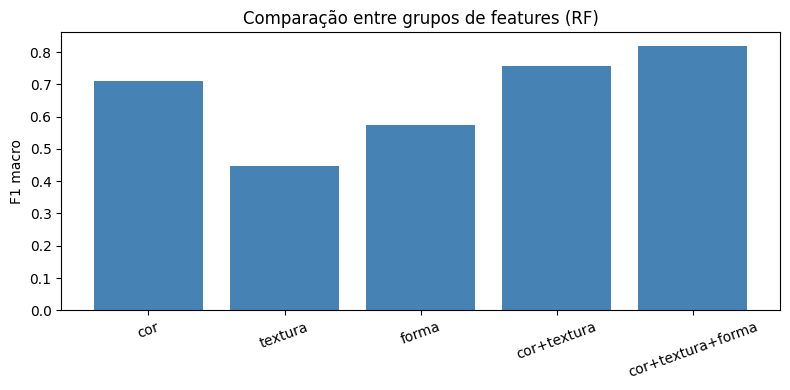

In [15]:
grupos = {
    'cor':              ['H_mean','S_mean','V_mean','frac_dark',
                         'hist_h_0','hist_h_1','hist_h_2','hist_h_3',
                         'hist_h_4','hist_h_5','hist_h_6','hist_h_7'],
    'textura':          ['glcm_contrast','glcm_homogeneity',
                         'glcm_energy','glcm_correlation','lbp_var'],
    'forma':            ['area','circularity','solidity','eccentricity',
                         'perimeter','extent','hu_1','hu_2','hu_3',
                         'hu_4','hu_5','hu_6','hu_7'],
    'cor+textura':      ['H_mean','S_mean','V_mean','frac_dark',
                         'hist_h_0','hist_h_1','hist_h_2','hist_h_3',
                         'hist_h_4','hist_h_5','hist_h_6','hist_h_7',
                         'glcm_contrast','glcm_homogeneity',
                         'glcm_energy','glcm_correlation','lbp_var'],
    'cor+textura+forma': feature_cols  # todas
}

modelo_ref = RandomForestClassifier(n_estimators=100, random_state=SEED)
resultados_grupos = {}

for nome_grupo, cols in grupos.items():
    cols_validas = [c for c in cols if c in feature_cols]
    idx = [feature_cols.index(c) for c in cols_validas]

    Xg_train = X_train_s[:, idx]
    Xg_val   = X_val_s[:, idx]
    Xg_test  = X_test_s[:, idx]

    modelo_ref.fit(
        np.vstack([Xg_train, Xg_val]),
        np.hstack([y_train, y_val])
    )
    res = avaliar(modelo_ref, Xg_test, y_test)
    resultados_grupos[nome_grupo] = res['f1']
    print(f'{nome_grupo:20s} — f1: {res["f1"]:.3f}')

# gráfico
plt.figure(figsize=(8, 4))
plt.bar(resultados_grupos.keys(), resultados_grupos.values(), color='steelblue')
plt.ylabel('F1 macro')
plt.title('Comparação entre grupos de features (RF)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('../outputs/tabela de métricas/comparacao_grupos_features.png')
plt.show()
